In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
# import psycopg2
from datetime import datetime, timedelta
import sqlite3

In [ ]:
# Read in all the csv files from the data folder and save them as a dictionary of DataFrames
data_dir = Path('/content/')
dfs = {}

try:
    for file_path in data_dir.glob('*.csv'):
        if file_path.is_file():
            # Get the filename without extension
            file_name = file_path.stem
            df = pd.read_csv(file_path)
            dfs[file_name] = df
except Exception as e:
    print(f"Error occurred: {e}")

# Check the keys of the dictionary
print(dfs.keys())

# Save each DataFrame as individual dfs
for key, df in dfs.items():
    globals()[f'df_{key}'] = df

dict_keys(['photo_tags', 'photos', 'follows', 'users', 'comments', 'likes', 'tags'])


In [ ]:
# Check for nulls in each df
for key, df in dfs.items():
    print(f"Nulls in DataFrame {key}:")
    print(df.isnull().sum().sum())

In [34]:
# Replace spaces with underscores in the column names and make all lowercase
for key, df in dfs.items():
    df.columns = df.columns.str.replace(' ', '_')
    df.columns = df.columns.str.lower()


In [ ]:
# Change yes/no columns to boolean values and data type
for key, df in dfs.items():
    for col in df.columns:
        # If columns only contain yes or no, change to boolean
        if df[col].isin(['yes', 'no']).all():
            df[col] = df[col].map({'yes': True, 'no': False})


In [ ]:
# Convert the created columns to datetime data type
date_time_cols = ['created_dat','created_date', 'created_time', 'created_timestamp']

for key, df in dfs.items():
    for col in date_time_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')  # Coerce will return NaT for invalid dates

In [ ]:
# Create new id columns for the likes and follows dataframes as they will be used as foreign keys in the interactions table
df_likes['like_id'] = (df_likes.index + 1).astype(int)
df_follows['follow_id'] = df_follows.index + 1

In [29]:
# Rename the columns in each dataframe to match the database schema
# Using explicit assignment instead of inplace=True for robustness
df_photos = df_photos.rename(columns={'created dat': 'created_date','id':'photo_id', 'image link': 'image_link', 'user ID': 'user_id', 'Insta filter used': 'insta_filter_used', 'photo type': 'photo_type'})
df_users = df_users.rename(columns={'id': 'user_id','private/public':'private', 'created time': 'created_time', 'post count': 'post_count', 'verified_status': 'verified_status'})
df_tags = df_tags.rename(columns={'id': 'tag_id', 'tag text': 'tag_text', 'created time': 'created_time'})
df_comments = df_comments.rename(columns={'user__id': 'user_id','id':'comment_id','created_timestamp':'created_time'})
df_likes = df_likes.rename(columns={'user_': 'user_id', 'photo': 'photo_id'})
df_follows = df_follows.rename(columns={'follower': 'follower_user_id', 'followee_': 'user_id'})

In [ ]:
# Combine Likes, Comments, and Follows DataFrames into a single Interactions DataFrame

# Standardize column names for consistency before concatenation
for df_var in [df_likes, df_comments, df_follows]:
    df_var.columns = df_var.columns.str.replace(' ', '_').str.lower()

# Prepare df_follows to align 'user_id' with the actor (follower) for concatenation
# Create a copy to avoid modifying the original df_follows inadvertently for other uses
df_follows_temp = df_follows.copy()
# The 'user_id' in df_follows is currently the followee. We want the follower as 'user_id'.
# Rename 'user_id' (followee) to 'followed_user_id' to avoid conflict and retain information.
df_follows_temp = df_follows_temp.rename(columns={'user_id': 'followed_user_id'})
# Now, rename 'follower_user_id' to 'user_id' as this is the actor.
df_follows_temp = df_follows_temp.rename(columns={'follower_user_id': 'user_id'})

# Concatenate Likes, Comments, and the prepared Follows DataFrame
df_interactions = pd.concat([df_likes, df_comments, df_follows_temp], ignore_index=True)

# Create interaction_id column
df_interactions['interaction_id'] = df_interactions.index + 1

# Add a new column to indicate the type of interaction ('like', 'comment', or 'follow')
df_interactions['interaction_type'] = pd.Series(
    ['like'] * len(df_likes) +
    ['comment'] * len(df_comments) +
    ['follow'] * len(df_follows_temp)
)

# Add an interaction date column (you can use 'created_time' column or any other appropriate date column)
df_interactions['interaction_date'] = df_interactions['created_time']

# List of columns to keep
# Add 'followed_user_id' to keep the information about who was followed
keep_cols = ['interaction_id', 'interaction_type', 'interaction_date', 'user_id', 'photo_id', 'comment_id', 'like_id','follow_id', 'followed_user_id']

# Remove columns that are not in the keep_cols list
df_interactions = df_interactions[[col for col in df_interactions.columns if col in keep_cols]]

# Make sure the id columns are integers even though they contain NaN values
id_cols = ['user_id', 'photo_id', 'comment_id', 'like_id', 'follow_id', 'followed_user_id'] # Add followed_user_id
for col in id_cols:
    if col in df_interactions.columns: # Add a check to prevent KeyError if a column is missing after filtering
        df_interactions[col] = df_interactions[col].astype('Int64')

In [31]:
# Define the database file
db_file = '/content/insta_lite.db'

# Connect to the database
conn = sqlite3.connect(db_file)
cursor = conn.cursor()

# Drop table if it exists to ensure schema consistency
cursor.execute('DROP TABLE IF EXISTS users')
# Create the Users table
cursor.execute('''CREATE TABLE IF NOT EXISTS users (
                    user_id INTEGER PRIMARY KEY,
                    name TEXT,
                    created_time DATE,
                    private BOOLEAN,
                    post_count INTEGER,
                    verified_status BOOLEAN
                )''')

# Convert DataFrame to data in the Users table
df_users.to_sql('users', conn, if_exists='append', index=False)
print("Rows in Users table:", cursor.execute('SELECT COUNT(*) FROM users').fetchone()[0])

# Drop table if it exists to ensure schema consistency
cursor.execute('DROP TABLE IF EXISTS photos')
# Create the Photos table
cursor.execute('''CREATE TABLE IF NOT EXISTS photos (
                    photo_id INTEGER PRIMARY KEY,
                    image_link TEXT,
                    user_id INTEGER,
                    created_date DATE,
                    insta_filter_used BOOLEAN,
                    photo_type TEXT,
                    FOREIGN KEY (user_id) REFERENCES users(user_id)
                )''')

# Convert DataFrame to data in the Photos table
df_photos.to_sql('photos', conn, if_exists='append', index=False)
print("Rows in Photos table:", cursor.execute('SELECT COUNT(*) FROM photos').fetchone()[0])

# Drop table if it exists to ensure schema consistency
cursor.execute('DROP TABLE IF EXISTS tags')
# Create the Tags table
cursor.execute('''CREATE TABLE IF NOT EXISTS tags (
                    tag_id INTEGER PRIMARY KEY,
                    tag_text TEXT,
                    created_time DATE,
                    location TEXT
                )''')

# Convert DataFrame to data in the Tags table
df_tags.to_sql('tags', conn, if_exists='append', index=False)
print("Rows in Tags table:", cursor.execute('SELECT COUNT(*) FROM tags').fetchone()[0])

# Drop table if it exists to ensure schema consistency
cursor.execute('DROP TABLE IF EXISTS comments')
# Create the Comments table
cursor.execute('''CREATE TABLE IF NOT EXISTS comments (
                    comment_id INTEGER PRIMARY KEY,
                    user_id INTEGER,
                    photo_id INTEGER,
                    created_time DATETIME,
                    posted_date TEXT,
                    comment TEXT,
                    emoji_used BOOLEAN,
                    hashtags_used_count INTEGER,
                    FOREIGN KEY (user_id) REFERENCES users(user_id),
                    FOREIGN KEY (photo_id) REFERENCES photos(photo_id)
                )''')

# Convert DataFrame to data in the Comments table
df_comments.to_sql('comments', conn, if_exists='append', index=False)
print("Rows in Comments table:", cursor.execute('SELECT COUNT(*) FROM comments').fetchone()[0])

# Drop table if it exists to ensure schema consistency
cursor.execute('DROP TABLE IF EXISTS likes')
# Create the Likes table
cursor.execute('''CREATE TABLE IF NOT EXISTS likes (
                    like_id INTEGER PRIMARY KEY,
                    user_id INTEGER,
                    photo_id INTEGER,
                    created_time DATE,
                    following_or_not BOOLEAN,
                    like_type TEXT,
                    FOREIGN KEY (user_id) REFERENCES users(user_id),
                    FOREIGN KEY (photo_id) REFERENCES photos(photo_id)
                )''')

# Convert DataFrame to data in the Likes table
df_likes.to_sql('likes', conn, if_exists='append', index=False)
print("Rows in Likes table:", cursor.execute('SELECT COUNT(*) FROM likes').fetchone()[0])

# Drop table if it exists to ensure schema consistency
cursor.execute('DROP TABLE IF EXISTS follows')
# Create the Follows table
cursor.execute('''CREATE TABLE IF NOT EXISTS follows (
                    follow_id INTEGER PRIMARY KEY,
                    follower_user_id INTEGER,
                    user_id INTEGER,
                    created_time DATE,
                    is_follower_active INTEGER,
                    followee_acc_status TEXT,
                    FOREIGN KEY (follower_user_id) REFERENCES users(user_id),
                    FOREIGN KEY (user_id) REFERENCES users(user_id)
                )''')

# Convert DataFrame to data in the Follows table
df_follows.to_sql('follows', conn, if_exists='append', index=False)
print("Rows in Follows table:", cursor.execute('SELECT COUNT(*) FROM follows').fetchone()[0])

# Drop table if it exists to ensure schema consistency
cursor.execute('DROP TABLE IF EXISTS interactions')
# Create the Interactions table
cursor.execute('''CREATE TABLE IF NOT EXISTS interactions (
                    interaction_id INTEGER PRIMARY KEY,
                    user_id INTEGER,
                    photo_id INTEGER,
                    tag_id INTEGER,
                    comment_id INTEGER,
                    like_id INTEGER,
                    follow_id INTEGER,
                    followed_user_id INTEGER, -- Added this column
                    interaction_date DATE,
                    interaction_type TEXT,
                    FOREIGN KEY (user_id) REFERENCES users(user_id),
                    FOREIGN KEY (photo_id) REFERENCES photos(photo_id),
                    FOREIGN KEY (tag_id) REFERENCES tags(tag_id),
                    FOREIGN KEY (comment_id) REFERENCES comments(comment_id),
                    FOREIGN KEY (like_id) REFERENCES likes(like_id),
                    FOREIGN KEY (follow_id) REFERENCES follows(follow_id),
                    FOREIGN KEY (followed_user_id) REFERENCES users(user_id) -- Added this foreign key
                )''')

# Convert DataFrame to data in the Interactions table
df_interactions.to_sql('interactions', conn, if_exists='append', index=False)
print("Rows in Interactions table:", cursor.execute('SELECT COUNT(*) FROM interactions').fetchone()[0])

# Commit the changes and close the connection
conn.commit()
conn.close()

Rows in Users table: 100
Rows in Photos table: 257
Rows in Tags table: 21
Rows in Comments table: 7488
Rows in Likes table: 8782
Rows in Follows table: 7623
Rows in Interactions table: 23893


In [33]:
# Connect to the SQLite database
db_path = "/content/insta_lite.db"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Query and print the # of photos in the photos table
cursor.execute("SELECT COUNT(*) FROM photos")
photo_count = cursor.fetchone()[0]
print(f"Number of photos in the photos table: {photo_count}")

# Query and print the # of users in the users table
cursor.execute("SELECT COUNT(*) FROM users")
user_count = cursor.fetchone()[0]
print(f"Number of users in the users table: {user_count}")

# Query the count of distinct tags in the tags table
cursor.execute("SELECT COUNT(DISTINCT tag_id) FROM tags")
tag_count = cursor.fetchone()[0]
print(f"Number of tags in the tags table: {tag_count}")

# Query and print the # of likes in the interactions table
cursor.execute("SELECT COUNT(*) FROM interactions WHERE interaction_type = 'like'")
like_count = cursor.fetchone()[0]
print(f"Number of likes in the interactions table: {like_count}")

# Query and print the # of comments in the interactions table
cursor.execute("SELECT COUNT(*) FROM interactions WHERE interaction_type = 'comment'")
comment_count = cursor.fetchone()[0]
print(f"Number of comments in the interactions table: {comment_count}")

# Query and print the # of follows in the interactions table
cursor.execute("SELECT COUNT(*) FROM interactions WHERE interaction_type = 'follow'")
follow_count = cursor.fetchone()[0]
print(f"Number of follows in the interactions table: {follow_count}")

# Close the connection
conn.close()

Number of photos in the photos table: 257
Number of users in the users table: 100
Number of tags in the tags table: 21
Number of likes in the interactions table: 8782
Number of comments in the interactions table: 7488
Number of follows in the interactions table: 7623


In [35]:
# Load data from DB
conn = sqlite3.connect("/content/insta_lite.db")

df_photos = pd.read_sql("SELECT * FROM photos", conn)
df_likes = pd.read_sql("SELECT * FROM likes", conn)
df_comments = pd.read_sql("SELECT * FROM comments", conn)
df_users = pd.read_sql("SELECT * FROM users", conn)

# Likes per photo
likes_per_photo = df_likes.groupby('photo_id').size().reset_index(name='likes_count')

# Comments per photo
comments_per_photo = df_comments.groupby('photo_id').size().reset_index(name='comments_count')

# Merge with photos
df_engagement = df_photos.merge(likes_per_photo, on='photo_id', how='left')
df_engagement = df_engagement.merge(comments_per_photo, on='photo_id', how='left')

# Fill nulls
df_engagement[['likes_count', 'comments_count']] = df_engagement[['likes_count', 'comments_count']].fillna(0)

# Add follower count per user
followers = pd.read_sql("""
SELECT user_id, COUNT(*) as follower_count
FROM follows
GROUP BY user_id
""", conn)

df_engagement = df_engagement.merge(followers, on='user_id', how='left')
df_engagement['follower_count'] = df_engagement['follower_count'].fillna(1)

# Engagement rate
df_engagement['engagement_rate'] = (
    (df_engagement['likes_count'] + df_engagement['comments_count']) /
    df_engagement['follower_count']
)

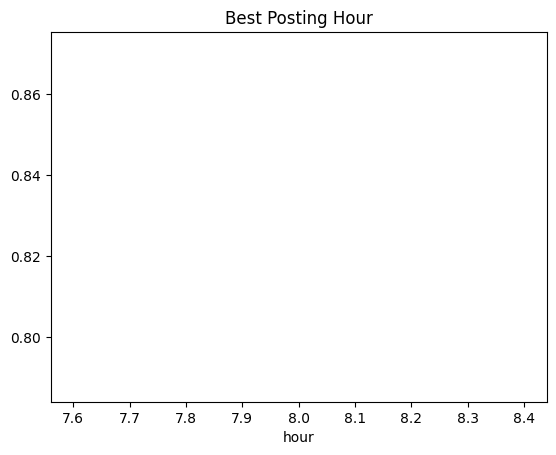

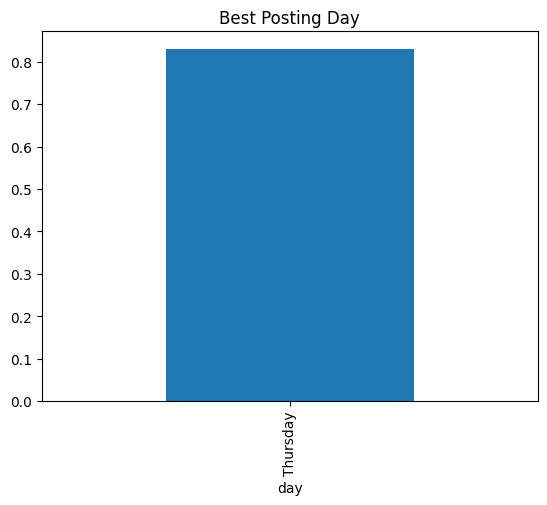

In [42]:
df_engagement['created_date'] = pd.to_datetime(df_engagement['created_date'])

df_engagement['hour'] = df_engagement['created_date'].dt.hour
df_engagement['day'] = df_engagement['created_date'].dt.day_name()

# Avg engagement by hour
hourly_engagement = df_engagement.groupby('hour')['engagement_rate'].mean()

hourly_engagement.plot(kind='line', title="Best Posting Hour")
plt.show()

# Avg engagement by day
daily_engagement = df_engagement.groupby('day')['engagement_rate'].mean().sort_values()

daily_engagement.plot(kind='bar', title="Best Posting Day")
plt.show()

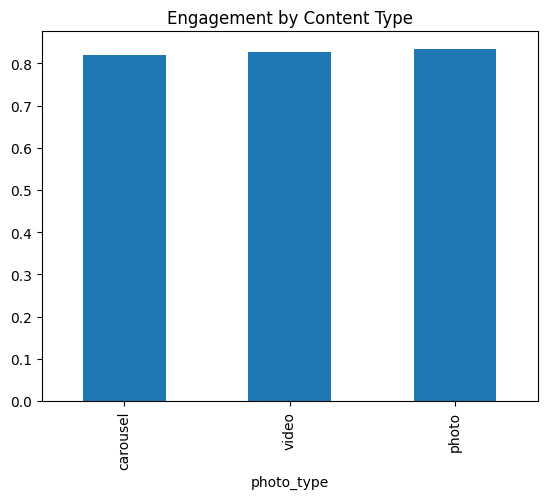

In [37]:
content_analysis = df_engagement.groupby('photo_type')['engagement_rate'].mean().sort_values()

content_analysis.plot(kind='bar', title="Engagement by Content Type")
plt.show()

In [44]:
print("\n===== KEY INSIGHTS =====")

best_hour = hourly_engagement.idxmax()
print(f"Best posting hour: {best_hour}:00")

best_day = daily_engagement.idxmax()
print(f"Best posting day: {best_day}")

if 'photo_type' in df_engagement.columns:
    best_content = content_analysis.idxmax()
    print(f"Best content type: {best_content}")


===== KEY INSIGHTS =====
Best posting hour: 8:00
Best posting day: Thursday
Best content type: photo
